In [15]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from enum import Enum, auto
from tqdm import tqdm
from statistics import mean

In [16]:
class ImmunisationStrategy(Enum):
    RANDOM = auto()
    TARGETED = auto()

In [17]:
def find_largest_neighbor(graph, node):
    neighbors = list(graph.neighbors(node))
    if not neighbors:
        return None

    return max(neighbors, key=lambda n: graph.degree(n), default=None)

def simulate_infection_with_immunity(network, infection_rate, recovery_rate, initial_infected_node, immune_nodes, time_steps=10): #1000
    infected = {initial_infected_node}
    probabilities_infected_list = []

    current_step = 0
    while current_step < time_steps:
        for infected_node in infected.copy():
            if np.random.rand() < recovery_rate:
                infected.remove(infected_node)

            notImmunizedNeigh = set(network.neighbors(infected_node)).difference(immune_nodes)

            for neighbor in notImmunizedNeigh.difference(infected):
                if np.random.rand() < infection_rate:
                    infected.add(neighbor)

        probability_infected = len(infected) / len(network.nodes())

        probabilities_infected_list.append(probability_infected)

        current_step += 1

    if len(probabilities_infected_list) > 0:
        res = mean(probabilities_infected_list)
    else:
        res = 0

    return res

def select_immune_nodes(graph, fraction, strategy):
    graph_nodes = list(graph.nodes())
    np.random.shuffle(graph_nodes)
    num_node_selection = int(fraction * len(graph.nodes()))

    if strategy == ImmunisationStrategy.RANDOM:
        immune_nodes = set(np.random.choice(graph_nodes, num_node_selection, replace=False))
    elif strategy == ImmunisationStrategy.TARGETED:
        immune_nodes = {find_largest_neighbor(graph, node) for node in graph_nodes[:num_node_selection] if find_largest_neighbor(graph, node) is not None}
    else:
        raise ValueError("Invalid immunisation strategy")

    return immune_nodes

In [18]:
def perform_infection_simulations_with_immunity(graph, infection_rate, recovery_rate, immunity_fractions, immunity_strategy):
    num_simulations = 100
    num_time_steps = 1000

    probabilities_infected = []

    for g in tqdm(immunity_fractions, desc=f"Progress {immunity_strategy} strategy: "):
        probabilities_avg = simulate_infections_for_fraction(graph, num_simulations, infection_rate, recovery_rate, immunity_strategy, g, num_time_steps)
        probabilities_infected.append(mean(probabilities_avg))

    return probabilities_infected, num_simulations, num_time_steps


def simulate_infections_for_fraction(graph, num_simulations, infection_rate, recovery_rate, immunity_strategy, g, num_time_steps):
    probabilities_avg = []

    for _ in range(num_simulations):
        initial_infected_node = np.random.choice(list(graph.nodes()))
        immune_nodes = select_immune_nodes(graph, g, immunity_strategy)
        probability_infected = simulate_infection_with_immunity(
            network=graph,
            infection_rate=infection_rate,
            recovery_rate=recovery_rate,
            initial_infected_node=initial_infected_node,
            immune_nodes=immune_nodes,
            time_steps=num_time_steps,
        )
        probabilities_avg.append(probability_infected)

    return probabilities_avg

In [19]:
def generate_barabasi_albert_graph():
    graph = nx.barabasi_albert_graph(n=50, m=3) #1000
    g_values = list(np.linspace(0, 1, 10)) # 10 hinten
    beta, gamma = 0.3, 0.6

    return (
        *perform_immunization_simulations(graph, beta, gamma, ImmunisationStrategy.RANDOM, g_values),
        *perform_immunization_simulations(graph, beta, gamma, ImmunisationStrategy.TARGETED, g_values),
    )


def perform_immunization_simulations(graph, beta, gamma, strategy, g_values):
    return (*perform_infection_simulations_with_immunity(graph, beta, gamma, g_values, strategy),)


Progress ImmunisationStrategy.RANDOM strategy:   0%|          | 0/10 [00:00<?, ?it/s]

Progress ImmunisationStrategy.TARGETED strategy: 100%|██████████| 10/10 [00:19<00:00,  1.99s/it]


ValueError: x and y must have same first dimension, but have shapes (1,) and (10,)

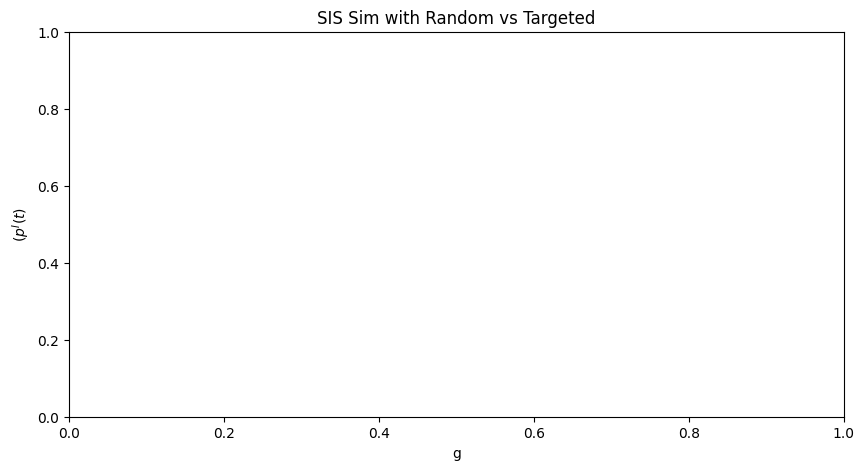

In [20]:
def plot_sis_sim():

    immunity_random, immunity_targeted, g, _, num_simulations, num_time_steps = generate_barabasi_albert_graph() # main action

    fig, ax = plt.subplots(1, 1, figsize=(10, 5))

    ax.set(title="SIS Sim with Random vs Targeted",
           xlabel="g",
           ylabel="($p^I(t\approx\infty)$)",
           ylim=(0, 1),
           xlim=(0, 1))

    ax.plot(g,immunity_random,label="Random",linestyle='-', color='blue', marker="o",ms=2,)
    ax.plot(g,immunity_targeted,label="Targeted",linestyle='--', color='green', marker="o",ms=2,)
    ax.legend()

plot_sis_sim()
plt.show()
